# Pixels to Predictions v6 — Metadata + Choice Shuffling + Weighted Loss

**Model:** `HuggingFaceTB/SmolVLM-500M-Instruct`  
**Base:** v5 (0.79476 Kaggle)

**What changed from v5:**
- Metadata in prompt (subject, topic, grade)
- Choice order shuffling per sample (reduces position bias)
- Weighted loss: 5-choice questions get 3x weight
- 5 epochs with LR 1e-4 (v5 used 3 epochs, LR 2e-4)

**Unchanged from v5:** 768px resolution, LoRA r=16 attn-only, digit logit scoring, batch_size=2, grad_accum=8

## 0. Install Dependencies

In [1]:
# Upgrade transformers for SmolVLM support
!pip install -q "transformers==4.47.0"

# Remove Colab's old torchao — peft crashes if it finds torchao < 0.16.0
!pip uninstall -y torchao 2>/dev/null

# Install remaining dependencies
!pip install -q accelerate peft bitsandbytes datasets pillow tqdm pandas

# Verify
import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print("All good. If first run, do Runtime -> Restart session, then run all cells.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 108.7 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.4 MB/s eta 0:00:00
transformers: 4.47.0
peft: 0.18.1
All good. If first run, do Runtime -> Restart session, then run all cells.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [4]:
import transformers
print(f"transformers: {transformers.__version__}")
assert transformers.__version__ >= "4.45.0", f"Too old: {transformers.__version__}"

import os, json, re, random
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

# ── Config ──────────────────────────────────────────────────
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

DATA_DIR = "/content/drive/MyDrive/pixels-to-predictions"
IMG_BASE = os.path.join(DATA_DIR, "images")

OUTPUT_DIR = "/content/smolvlm-lora-v6"
CKPT_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v6"
os.makedirs(CKPT_DIR, exist_ok=True)

# ── LoRA config — same as v5 ────────────────────────────────
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# ── Image resolution — same as v5 ──────────────────────────
IMAGE_LONGEST_EDGE = 768

# ── Training hyperparameters — CHANGED ──────────────────────
LEARNING_RATE = 1e-4      # v5 used 2e-4; slower for more epochs
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8      # effective batch size = 16
NUM_EPOCHS = 5            # v5 used 3; more epochs with lower LR
WARMUP_RATIO = 0.1
MAX_SEQ_LEN = 1024
SEED = 42

# ── Weighted loss config ────────────────────────────────────
WEIGHT_5_CHOICE = 3.0     # 5-choice questions get 3x loss weight

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

transformers: 4.47.0
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB


## 2. Load Data

In [5]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Show num_choices distribution
print(f"\nTrain num_choices distribution:")
print(train_df['num_choices'].value_counts().sort_index())

sample_path = os.path.join(IMG_BASE, train_df['image_path'].iloc[0])
assert os.path.exists(sample_path), f"Image not found: {sample_path}"
print(f"\nImages accessible at {IMG_BASE}")

Train: 3109 | Val: 1048 | Test: 1008

Train num_choices distribution:
num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64

Images accessible at /content/drive/MyDrive/pixels-to-predictions/images


## 3. Load Model & Processor

In [6]:
processor = AutoProcessor.from_pretrained(MODEL_ID)

# Must set BOTH max_image_size (tile size) AND image_seq_len to match
# Formula: image_seq_len = ((max_image_size // patch_size) ** 2) // (scale_factor ** 2)
# SmolVLM: patch_size=16, scale_factor=4
# 768 -> ((768//16)**2) // (4**2) = 2304 // 16 = 144
processor.image_processor.size = {"longest_edge": IMAGE_LONGEST_EDGE}
processor.image_processor.max_image_size = {"longest_edge": IMAGE_LONGEST_EDGE}
processor.image_seq_len = ((IMAGE_LONGEST_EDGE // 16) ** 2) // (4 ** 2)

print(f"Image processor size: {processor.image_processor.size}")
print(f"Max image size (tile): {processor.image_processor.max_image_size}")
print(f"Image seq len: {processor.image_seq_len}")

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"Model type: {type(model).__name__}")

# Quick sanity check
test_img = Image.new('RGB', (768, 768))
test_inputs = processor(text="<image>test", images=[test_img], return_tensors="pt")
print(f"Tiles for 768x768 image: {test_inputs['pixel_values'].shape}")
print(f"Input IDs shape: {test_inputs['input_ids'].shape}")
del test_img, test_inputs

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Image processor size: {'longest_edge': 768}
Max image size (tile): {'longest_edge': 768}
Image seq len: 144


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model type: Idefics3ForConditionalGeneration
Tiles for 768x768 image: torch.Size([1, 1, 3, 768, 768])
Input IDs shape: torch.Size([1, 148])


## 4. Apply LoRA

In [7]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.CAUSAL_LM,
    bias="none",
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Total parameters:     {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable %:          {100 * trainable_params / total_params:.2f}%")

assert trainable_params <= 5_000_000, f"OVER BUDGET: {trainable_params:,} > 5,000,000"
print(f"\nUnder 5M cap ({trainable_params:,} <= 5,000,000)")

Trainable parameters: 4,161,536 (4.16M)
Total parameters:     511,643,840 (511.6M)
Trainable %:          0.81%

Under 5M cap (4,161,536 <= 5,000,000)


## 5. Prompt & Dataset (with metadata + choice shuffling)

In [8]:
def build_prompt(row, include_answer=False, shuffle_choices=False):
    """Build prompt with metadata and optional choice shuffling.

    Changes from v5:
    - Adds subject, topic, grade as metadata header
    - shuffle_choices: randomly reorder choices and remap answer index
    """
    choices = json.loads(row['choices'])
    answer = int(row['answer']) if include_answer else None

    # Shuffle choices if requested (training only)
    if shuffle_choices and include_answer:
        indices = list(range(len(choices)))
        random.shuffle(indices)
        choices = [choices[i] for i in indices]
        answer = indices.index(answer)  # remap answer to new position

    choices_text = "\n".join(f"({i}) {c}" for i, c in enumerate(choices))

    parts = []

    # NEW: metadata header
    meta_parts = []
    if pd.notna(row.get('subject', None)):
        meta_parts.append(f"Subject: {row['subject']}")
    if pd.notna(row.get('topic', None)):
        meta_parts.append(f"Topic: {row['topic']}")
    if pd.notna(row.get('grade', None)):
        meta_parts.append(f"Grade: {row['grade']}")
    if meta_parts:
        parts.append(" | ".join(meta_parts))

    if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
        parts.append(f"Context: {row['hint'].strip()}")
    if pd.notna(row.get('lecture', None)) and str(row['lecture']).strip():
        parts.append(f"Background: {row['lecture'].strip()}")

    parts.append(f"Question: {row['question'].strip()}")
    parts.append(f"Choices:\n{choices_text}")
    parts.append("Answer with ONLY the number of the correct choice.")

    prompt_text = "\n\n".join(parts)

    if include_answer:
        answer_text = str(answer)
        return prompt_text, answer_text
    return prompt_text


# Show sample with metadata
sample = train_df.iloc[0]
prompt, answer = build_prompt(sample, include_answer=True, shuffle_choices=False)
print("SAMPLE PROMPT (no shuffle):")
print(prompt[:400])
print(f"\n>>> TARGET ANSWER: {answer}")

print("\n" + "="*50)

# Show same sample with shuffled choices
prompt_s, answer_s = build_prompt(sample, include_answer=True, shuffle_choices=True)
print("\nSAMPLE PROMPT (shuffled):")
print(prompt_s[:400])
print(f"\n>>> TARGET ANSWER: {answer_s}")

SAMPLE PROMPT (no shuffle):
Subject: natural science | Topic: literacy-in-science | Grade: grade8

Context: Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific animal behavior. Then, follow the instructions below.

Amazonian poison frogs live in tropical forests in northern South America. After a male and female frog mate, the female frog lays eggs on a plant. 

>>> TARGET ANSWER: 2


SAMPLE PROMPT (shuffled):
Subject: natural science | Topic: literacy-in-science | Grade: grade8

Context: Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific animal behavior. Then, follow the instructions below.

Amazonian poison frogs live in tropical forests in northern South America. After a male and female frog mate, the female frog lays eggs on a plant. 

>>> TARGET ANSWER: 2


In [9]:
class ScienceVQADataset(Dataset):
    def __init__(self, df, img_base, is_test=False, shuffle_choices=False):
        self.df = df.reset_index(drop=True)
        self.img_base = img_base
        self.is_test = is_test
        self.shuffle_choices = shuffle_choices

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_base, row['image_path'])
        image = Image.open(img_path).convert("RGB")

        if self.is_test:
            prompt_text = build_prompt(row, include_answer=False, shuffle_choices=False)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": None, "is_test": True, "num_choices": row["num_choices"]}
        else:
            prompt_text, answer_text = build_prompt(
                row, include_answer=True, shuffle_choices=self.shuffle_choices)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": answer_text, "is_test": False,
                    "num_choices": row["num_choices"]}


train_dataset = ScienceVQADataset(train_df, IMG_BASE, is_test=False, shuffle_choices=True)
val_dataset = ScienceVQADataset(val_df, IMG_BASE, is_test=False, shuffle_choices=False)
test_dataset = ScienceVQADataset(test_df, IMG_BASE, is_test=True, shuffle_choices=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3109 | Val: 1048 | Test: 1008


## 6. DataLoaders (with weighted loss support)

In [10]:
from functools import partial

def collate_fn(batch, processor, max_length=MAX_SEQ_LEN):
    """Collate with per-sample loss weights based on num_choices."""
    ids = [item["id"] for item in batch]
    images = [item["image"] for item in batch]
    is_test = batch[0]["is_test"]
    num_choices_list = [item["num_choices"] for item in batch]

    texts = []
    answer_texts = []
    for item in batch:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": item["prompt_text"]},
        ]}]
        if not is_test:
            messages.append({"role": "assistant", "content": [
                {"type": "text", "text": item["answer_text"]},
            ]})
            answer_texts.append(item["answer_text"])
        text = processor.apply_chat_template(messages, add_generation_prompt=is_test)
        texts.append(text)

    inputs = processor(
        text=texts, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=max_length,
    )

    if not is_test:
        labels = inputs["input_ids"].clone()
        eos_token_id = processor.tokenizer.eos_token_id

        for i in range(len(batch)):
            labels[i, :] = -100

            eos_positions = (inputs["input_ids"][i] == eos_token_id).nonzero(as_tuple=True)[0]
            if len(eos_positions) < 1:
                continue
            last_eos_pos = eos_positions[-1].item()

            ans_tokens = processor.tokenizer.encode(answer_texts[i], add_special_tokens=False)
            n_ans = len(ans_tokens)
            start = last_eos_pos - n_ans

            labels[i, start:last_eos_pos] = inputs["input_ids"][i, start:last_eos_pos]
            labels[i, last_eos_pos] = eos_token_id

        inputs["labels"] = labels

    inputs["id"] = ids
    inputs["num_choices"] = num_choices_list
    return dict(inputs)


collate = partial(collate_fn, processor=processor)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

# Verify labels
sample_batch = next(iter(val_loader))
print(f"\ninput_ids: {sample_batch['input_ids'].shape}")
print(f"pixel_values: {sample_batch['pixel_values'].shape}")
for i in range(min(2, len(sample_batch['id']))):
    label_mask = sample_batch['labels'][i] != -100
    label_positions = label_mask.nonzero(as_tuple=True)[0]
    labeled_tokens = sample_batch['labels'][i][label_positions]
    decoded = processor.tokenizer.decode(labeled_tokens)
    nc = sample_batch['num_choices'][i]
    print(f"  Sample {i}: '{decoded.strip()}' (num_choices={nc})")

Train batches: 1555 | Val batches: 524
Effective batch size: 16

input_ids: torch.Size([2, 654])
pixel_values: torch.Size([2, 1, 3, 768, 768])
  Sample 0: '0<end_of_utterance>' (num_choices=3)
  Sample 1: '1<end_of_utterance>' (num_choices=3)


## 7. Training Loop (with weighted loss)

In [11]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"Steps per epoch: {len(train_loader) // GRAD_ACCUM_STEPS}")

Total steps: 970 | Warmup: 97
Steps per epoch: 194


In [12]:
@torch.no_grad()
def evaluate(model, dataloader, processor):
    """Teacher-forced val loss + accuracy."""
    model.eval()
    correct, total, total_loss, num_batches = 0, 0, 0, 0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        ids = batch.pop("id")
        num_choices = batch.pop("num_choices")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        outputs = model(**batch, labels=labels)
        total_loss += outputs.loss.item()
        num_batches += 1

        logits = outputs.logits
        for i in range(len(ids)):
            label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
            if len(label_positions) == 0:
                continue
            ans_pos = label_positions[0].item()
            pred_token = logits[i, ans_pos - 1, :].argmax().item()
            true_token = labels[i, ans_pos].item()
            if pred_token == true_token:
                correct += 1
            total += 1

    model.train()
    return total_loss / max(num_batches, 1), correct / max(total, 1)


print("Pre-training evaluation...")
val_loss, val_acc = evaluate(model, val_loader, processor)
print(f"Pre-training — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Pre-training evaluation...


Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]

Pre-training — Val Loss: 1.4677 | Val Acc: 0.4485


In [13]:
def compute_weighted_loss(model, batch_inputs, labels, num_choices_list):
    """Compute CE loss with per-sample weighting based on num_choices.
    5-choice questions get WEIGHT_5_CHOICE multiplier."""
    outputs = model(**batch_inputs)
    logits = outputs.logits  # (B, seq_len, vocab)

    # Shift for next-token prediction
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()

    B, T, V = shift_logits.shape

    # Per-token CE loss (no reduction)
    per_token_loss = F.cross_entropy(
        shift_logits.view(-1, V), shift_labels.view(-1),
        ignore_index=-100, reduction='none'
    ).view(B, T)

    # Per-sample mean loss
    valid_mask = (shift_labels != -100).float()
    per_sample_loss = (per_token_loss * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1)

    # Apply weights
    weights = torch.ones(B, device=per_sample_loss.device)
    for i, nc in enumerate(num_choices_list):
        if nc == 5:
            weights[i] = WEIGHT_5_CHOICE

    weighted_loss = (per_sample_loss * weights).mean()
    return weighted_loss


print(f"Weighted loss: 5-choice questions get {WEIGHT_5_CHOICE}x weight")

Weighted loss: 5-choice questions get 3.0x weight


In [14]:
# ── Checkpoint helpers ──────────────────────────────────────

def save_checkpoint(model, optimizer, scheduler, scaler, epoch, step,
                    best_val_acc, train_losses, val_losses, val_accs, path):
    model.save_pretrained(os.path.join(path, "lora_adapter"))
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch, "step": step,
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    }, os.path.join(path, "training_state.pt"))
    print(f"  Checkpoint saved to {path}")


def load_checkpoint(model, optimizer, scheduler, scaler, path):
    state_path = os.path.join(path, "training_state.pt")
    adapter_path = os.path.join(path, "lora_adapter")
    if not os.path.exists(state_path):
        return 0, 0, 0.0, [], [], []
    state = torch.load(state_path, map_location=device, weights_only=False)
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])
    if os.path.exists(adapter_path):
        model.load_adapter(adapter_path, adapter_name="default")
    print(f"  Resumed from epoch {state['epoch']+1}, best_acc={state['best_val_acc']:.4f}")
    return (state["epoch"], state["step"], state["best_val_acc"],
            state["train_losses"], state["val_losses"], state["val_accs"])


# ── Main Training Loop ──────────────────────────────────────

scaler = torch.amp.GradScaler("cuda")

start_epoch, start_step, best_val_acc, train_losses, val_losses, val_accs = \
    load_checkpoint(model, optimizer, scheduler, scaler, CKPT_DIR)

if start_epoch > 0:
    print(f"Resuming from epoch {start_epoch + 1}")
else:
    best_val_acc = 0.0
    train_losses, val_losses, val_accs = [], [], []
    print("Starting training from scratch")

model.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        if epoch == start_epoch and step < start_step:
            continue

        ids = batch.pop("id")
        num_choices_list = batch.pop("num_choices")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            loss = compute_weighted_loss(model, batch, labels, num_choices_list)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss / (step+1):.4f}"})

    start_step = 0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loss, val_acc = evaluate(model, val_loader, processor)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"  New best! Saved to {OUTPUT_DIR}")

    save_checkpoint(model, optimizer, scheduler, scaler, epoch, 0,
                    best_val_acc, train_losses, val_losses, val_accs, CKPT_DIR)

print(f"\n{'='*40}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

Starting training from scratch


Epoch 1/5:   0%|          | 0/1555 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]


Epoch 1/5
  Train Loss: 0.5744
  Val Loss:   0.3509
  Val Acc:    0.6956
  New best! Saved to /content/smolvlm-lora-v6
  Checkpoint saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v6


Epoch 2/5:   0%|          | 0/1555 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]


Epoch 4/5
  Train Loss: 0.2102
  Val Loss:   0.2902
  Val Acc:    0.7968
  New best! Saved to /content/smolvlm-lora-v6
  Checkpoint saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v6


Epoch 5/5:   0%|          | 0/1555 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/524 [00:00<?, ?it/s]


Epoch 5/5
  Train Loss: 0.1889
  Val Loss:   0.2869
  Val Acc:    0.7977
  New best! Saved to /content/smolvlm-lora-v6
  Checkpoint saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v6

Best Val Accuracy: 0.7977


## 8. Training Curves

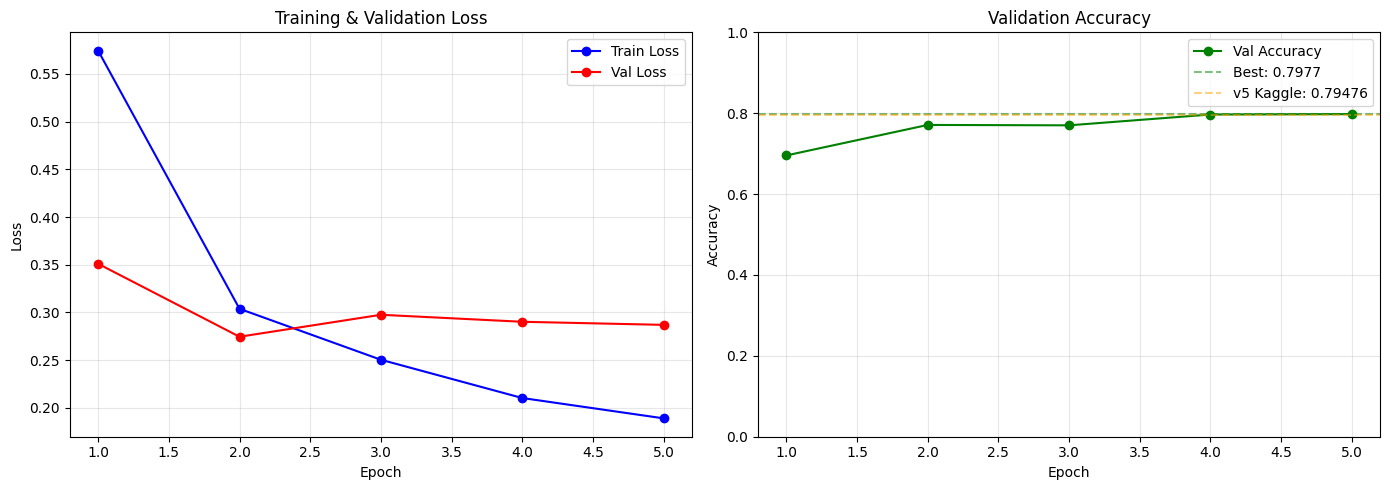

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_accs, 'g-o', label='Val Accuracy')
ax2.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
ax2.axhline(y=0.79476, color='orange', linestyle='--', alpha=0.5, label='v5 Kaggle: 0.79476')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Load Best Model for Inference

In [16]:
best_adapter_path = OUTPUT_DIR
if not os.path.exists(os.path.join(OUTPUT_DIR, "adapter_config.json")):
    best_adapter_path = os.path.join(CKPT_DIR, "lora_adapter")
    print(f"Local output missing, loading from Drive: {best_adapter_path}")

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(base_model, best_adapter_path)
model.eval()
print(f"Loaded best model from {best_adapter_path}")

Loaded best model from /content/smolvlm-lora-v6


## 10. Inference — Digit Logit Scoring

In [17]:
DIGIT_TOKEN_IDS = [processor.tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
print(f"Digit token IDs: { {d: DIGIT_TOKEN_IDS[d] for d in range(5)} }")


@torch.no_grad()
def predict_digit_logits(model, processor, df, img_base, batch_size=4):
    """Score digit-token logits at the last position."""
    model.eval()
    all_ids, all_preds = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="Predicting"):
        batch_df = df.iloc[start:start + batch_size]
        images, texts, batch_ids, nc_list = [], [], [], []

        for _, row in batch_df.iterrows():
            images.append(Image.open(os.path.join(img_base, row['image_path'])).convert("RGB"))
            prompt = build_prompt(row, include_answer=False, shuffle_choices=False)
            messages = [{"role": "user", "content": [
                {"type": "image"}, {"type": "text", "text": prompt}]}]
            texts.append(processor.apply_chat_template(messages, add_generation_prompt=True))
            batch_ids.append(row['id'])
            nc_list.append(row['num_choices'])

        inputs = processor(text=texts, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        logits = outputs.logits

        for i in range(len(batch_df)):
            last_pos = inputs["attention_mask"][i].sum().item() - 1
            next_logits = logits[i, last_pos, :]
            nc = nc_list[i]
            scores = torch.stack([next_logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
            all_preds.append(scores.argmax().item())
            all_ids.append(batch_ids[i])

    return all_ids, all_preds

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}


## 11. Val Accuracy (digit logits)

In [18]:
val_ids, val_preds = predict_digit_logits(model, processor, val_df, IMG_BASE, batch_size=4)
val_acc = np.mean([p == a for p, a in zip(val_preds, val_df['answer'].tolist())])
print(f"Val Accuracy (digit logits): {val_acc:.4f}")
print(f"vs v5 Kaggle (0.79476): {val_acc - 0.79476:+.4f}")

Predicting:   0%|          | 0/262 [00:00<?, ?it/s]

Val Accuracy (digit logits): 0.7710
vs v5 Kaggle (0.79476): -0.0238


## 12. Generate Test Predictions

In [19]:
print("Generating test predictions...")
test_ids, test_preds = predict_digit_logits(model, processor, test_df, IMG_BASE, batch_size=4)
print(f"Prediction distribution: {pd.Series(test_preds).value_counts().sort_index().to_dict()}")

Generating test predictions...


Predicting:   0%|          | 0/252 [00:00<?, ?it/s]

Prediction distribution: {0: 264, 1: 389, 2: 242, 3: 87, 4: 26}


In [20]:
submission = pd.DataFrame({"id": test_ids, "answer": test_preds})

sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert set(submission['id']) == set(sample_sub['id']), "ID mismatch!"
assert len(submission) == len(sample_sub), "Row count mismatch!"

submission = submission.set_index('id').loc[sample_sub['id']].reset_index()
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(f"Shape: {submission.shape}")
print(submission.head(10))
print(f"\nAnswer range: {submission['answer'].min()} to {submission['answer'].max()}")
print(f"Any NaN: {submission['answer'].isna().any()}")

Saved submission.csv
Shape: (1008, 2)
           id  answer
0  test_01750       2
1  test_00128       4
2  test_02891       4
3  test_02425       4
4  test_00930       4
5  test_03725       4
6  test_00009       1
7  test_02880       1
8  test_01208       1
9  test_00619       1

Answer range: 0 to 4
Any NaN: False


## 13. Error Analysis (Val Set)

In [21]:
val_results = val_df.copy()
val_results['predicted'] = val_preds
val_results['correct'] = val_results['predicted'] == val_results['answer']

print(f"Overall Val Accuracy (digit logits): {val_results['correct'].mean():.4f}")

print("\nAccuracy by Subject:")
for subj, group in val_results.groupby('subject'):
    acc = group['correct'].mean()
    print(f"  {subj:20s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by num_choices:")
for nc, group in val_results.groupby('num_choices'):
    acc = group['correct'].mean()
    print(f"  {nc} choices: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by Grade:")
for grade, group in val_results.sort_values('grade').groupby('grade'):
    acc = group['correct'].mean()
    print(f"  {grade:10s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nConfusion Matrix:")
print(pd.crosstab(val_results['answer'], val_results['predicted'],
                  rownames=['Actual'], colnames=['Predicted'], margins=True))

Overall Val Accuracy (digit logits): 0.7710

Accuracy by Subject:
  language science    : 0.5714 (16/28)
  natural science     : 0.7439 (578/777)
  social science      : 0.8807 (214/243)

Accuracy by num_choices:
  2 choices: 0.7992 (195/244)
  3 choices: 0.7677 (390/508)
  4 choices: 0.8373 (211/252)
  5 choices: 0.2727 (12/44)

Accuracy by Grade:
  grade1    : 1.0000 (1/1)
  grade10   : 1.0000 (1/1)
  grade12   : 0.3750 (3/8)
  grade2    : 0.8333 (30/36)
  grade3    : 0.8113 (86/106)
  grade4    : 0.8605 (148/172)
  grade5    : 0.7983 (95/119)
  grade6    : 0.7917 (152/192)
  grade7    : 0.7582 (138/182)
  grade8    : 0.6667 (154/231)

Confusion Matrix:
Predicted    0    1    2   3   4   All
Actual                                
0          218   86   33   5   5   347
1           18  311   31   6   6   372
2            6   18  215   6   2   247
3            3    3    5  58   6    75
4            0    0    0   1   6     7
All        245  418  284  76  25  1048


## 14. Verify Parameter Count

In [22]:
print("=" * 50)
print("PARAMETER BUDGET VERIFICATION")
print("=" * 50)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Trainable:  {trainable:>12,} ({trainable/1e6:.2f}M)")
print(f"Frozen:     {frozen:>12,} ({frozen/1e6:.1f}M)")
print(f"Total:      {trainable + frozen:>12,} ({(trainable + frozen)/1e6:.1f}M)")
print(f"")
print(f"Budget: {'PASS' if trainable <= 5_000_000 else 'FAIL'} ({trainable:,} {'<=' if trainable <= 5_000_000 else '>'} 5,000,000)")
print(f"")
print(f"Config: r={LORA_RANK}, alpha={LORA_ALPHA}")
print(f"Targets: q_proj, k_proj, v_proj, o_proj")
print(f"Image size: {IMAGE_LONGEST_EDGE}px")
print(f"")
print(f"V6 changes: metadata prompt, choice shuffling, weighted loss ({WEIGHT_5_CHOICE}x for 5-choice)")
print(f"LR: {LEARNING_RATE}, Epochs: {NUM_EPOCHS}")

PARAMETER BUDGET VERIFICATION
Trainable:             0 (0.00M)
Frozen:      511,643,840 (511.6M)
Total:       511,643,840 (511.6M)

Budget: PASS (0 <= 5,000,000)

Config: r=16, alpha=32
Targets: q_proj, k_proj, v_proj, o_proj
Image size: 768px

V6 changes: metadata prompt, choice shuffling, weighted loss (3.0x for 5-choice)
LR: 0.0001, Epochs: 5
